# 0.0 IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import inflection
import math
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image


### 0.1 Helper functions

### 0.2 Loading data

In [2]:
df_sales_raw = pd.read_csv('../Dados/train.csv', low_memory=False)
df_store_raw = pd.read_csv('../Dados/store.csv', low_memory=False)

#merge(uniao)

df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store') #o store é a coluna igual nos 2 df para fazer a união

# 1.0 DESCRIÇÃO DOS DADOS

In [3]:
df1 = df_raw.copy()

In [4]:
df_raw.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

### 1.1 Rename Columns

In [5]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
            'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
            'CompetitionDistance', 'CompetitionOpenSinceMonth',
            'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
            'Promo2SinceYear', 'PromoInterval']


snackcase = lambda x: inflection.underscore(x)

cols_new = list(map(snackcase, cols_old))

df1.columns = cols_new

### 1.2 Data Dimensions

In [6]:
print('n de linhas: {}'.format(df1.shape[0]))
print('n de colunas: {}'.format(df1.shape[1]))

n de linhas: 1017209
n de colunas: 18


### 1.3 Data Types

In [7]:
df1['date'] = pd.to_datetime(df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
dtype: object

### 1.4 Check NA

In [8]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

### 1.5 Fillout NA

In [9]:
# competition_distance	 
df1['competition_distance'] = df1['competition_distance'].fillna(200000.0)
      
# competition_open_since_month	
df1['competition_open_since_month'] = df1['competition_open_since_month'].fillna(df1['date'].dt.month)

# competition_open_since_year 
df1['competition_open_since_year'] = df1['competition_open_since_year'].fillna(df1['date'].dt.year)
	
# promo2_since_week	   
df1['promo2_since_week'] = df1['promo2_since_week'].fillna(df1['date'].dt.month)
 
# promo2_since_year   	
df1['promo2_since_year'] = df1['promo2_since_year'].fillna(df1['date'].dt.year)

# promo_interval	
month_map = {1: 'Jan',
 2: 'Fev',
 3: 'Mar',
 4: 'Apr',
 5: 'May',
 6: 'Jun',
 7: 'Jul',
 8: 'Aug',
 9: 'Set',
 10: 'Oct',
 11: 'Nov',
 12: 'Dec'} 

df1['promo_interval'].fillna(0,inplace=True) #inplace aplica o valor direto na coluna

df1['month_map'] = df1['date'].dt.month.map(month_map)

df1['is_promo'] = df1[['promo_interval','month_map']].apply( lambda x: 0 if x['promo_interval'] == 0 else 1 if x['month_map'] in x['promo_interval'].split(',') else 0, axis=1)


                

C:\Users\eduar\AppData\Local\Temp\ipykernel_8520\1312589929.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['promo_interval'].fillna(0,inplace=True) #inplace aplica o valor direto na coluna


### 1.6 Change Types

In [10]:
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype(int)
df1['promo2_since_week'] = df1['promo2_since_week'].astype(int)
df1['promo2_since_year'] = df1['promo2_since_year'].astype(int)

### 1.7 Description estatistic

In [11]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

### 1.7.1 Numerical attributes

In [12]:
#Medidas de têndencia central - mean, median
ct1 = pd.DataFrame( num_attributes.apply(np.mean) ).T
ct2 = pd.DataFrame( num_attributes.apply(np.median) ).T


#Medidas de disperção - min, max, range, kurtose, skew, std
d1 = pd.DataFrame(num_attributes.apply(np.std) ).T
d2 = pd.DataFrame(num_attributes.apply(np.min) ).T
d3 = pd.DataFrame(num_attributes.apply(np.max) ).T
d4 = pd.DataFrame((num_attributes.max() - num_attributes.min())).T
d5 = pd.DataFrame(num_attributes.skew() ).T
d6 = pd.DataFrame(num_attributes.kurtosis() ).T

#Concat
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']


#Maneira mais direta de fazer 

# m = pd.DataFrame({
#     'min': num_attributes.min(),
#     'max': num_attributes.max(),
#     'range': num_attributes.max() - num_attributes.min(),
#     'mean': num_attributes.mean(),
#     'median': num_attributes.median(),
#     'std': num_attributes.std(),
#     'skew': num_attributes.skew(),
#     'kurtosis': num_attributes.kurtosis()
# }).reset_index()

# m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']

In [13]:
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


C:\Users\eduar\AppData\Local\Temp\ipykernel_8520\710812770.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1['sales'])


<Axes: xlabel='sales', ylabel='Density'>

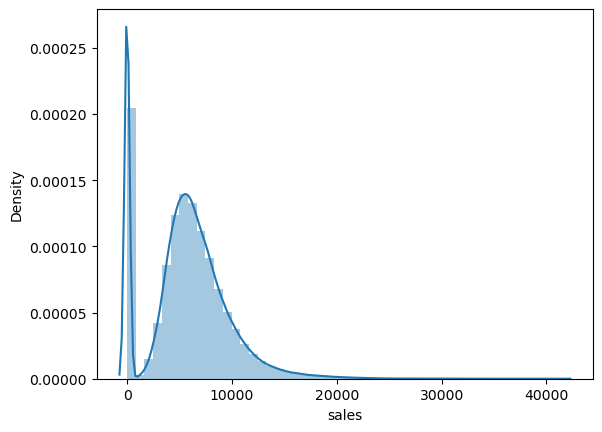

In [14]:
sns.distplot(df1['sales'])

### 1.7.2 Categorical attributes

In [15]:
cat_attributes.nunique()

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

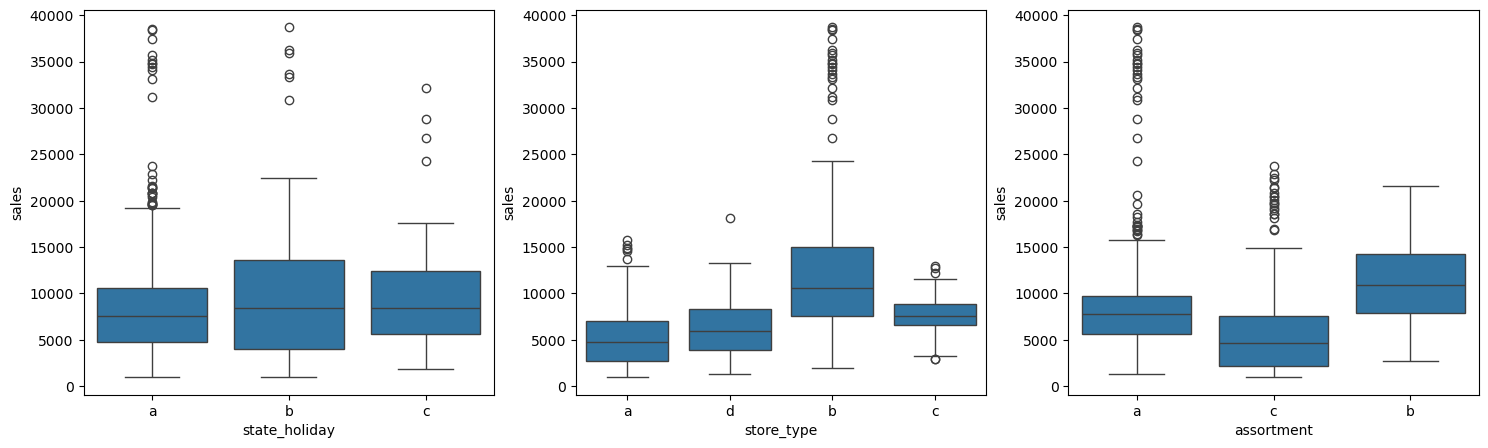

In [16]:
aux1 = df1[(df1['state_holiday'] != '0') & (df1['sales'] >0)]

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1,3,2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1,3,3)
sns.boxplot(x='assortment', y='sales', data=aux1)

plt.show()

# 2.0 FEATURE ENGINEERING

In [20]:
df2 = df1.copy()

### 2.1 Mapa de hipoteses

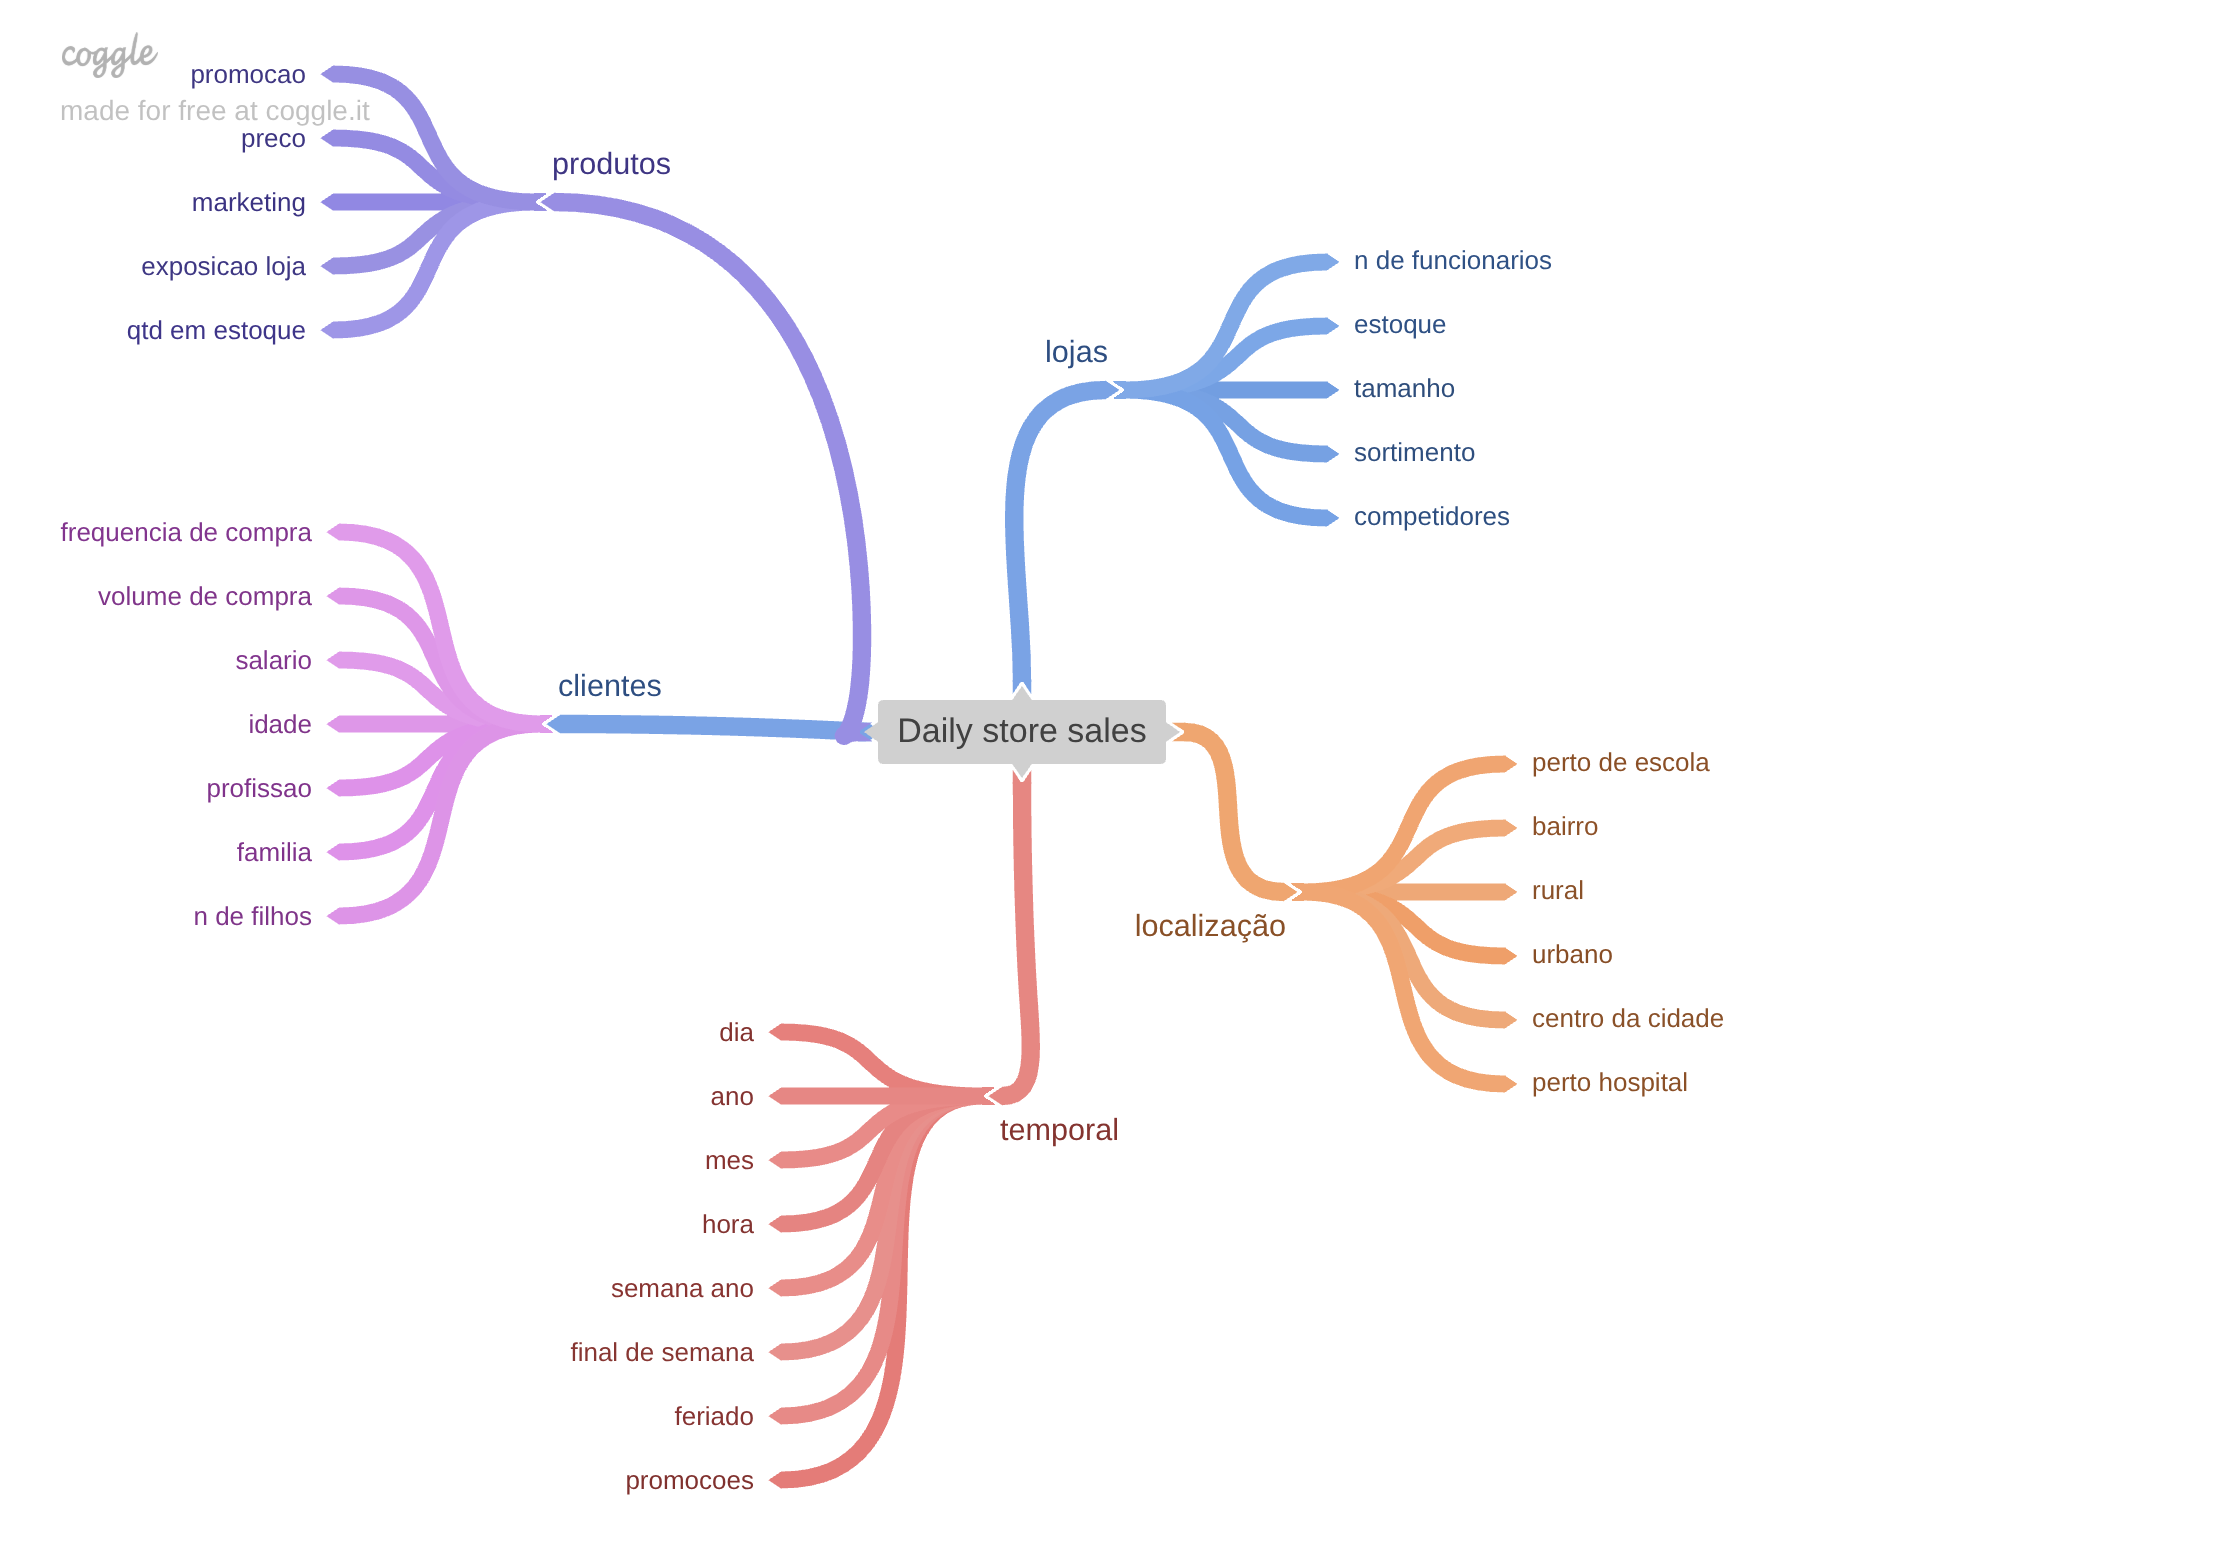

In [19]:
Image('../Img/BI.png')

### 2.1.1 Hipoteses das lojas

**1.** Lojas com número maior de funcionários deveriam vender mais.

**2.** Lojas com maior capacidade de estoque deveriam vender mais.

**3.** Lojas com maior porte deveriam vender mais.

**4.** Lojas com maior sortimentos deveriam vender mais.

**5.** Lojas com competidores mais próximos deveriam vender menos.

**6.** Lojas com competidores a mais longa distância deveriam vender mais.

### 2.1.1 Hipoteses dos produtos

**1.** Lojas que investem mais em Marketing deveriam vender mais.

**2.** Lojas com maior exposição de produto deveriam vender mais.

**3.** Lojas com produtos com preço menor deveriam vender mais.

**5.** Lojas com promoções mais agressivas ( descontos maiores ), deveriam vender mais.

**6.** Lojas com promoções ativas por mais tempo deveriam vender mais.

**7.** Lojas com mais dias de promoção deveriam vender mais.

**8.** Lojas com mais promoções consecutivas deveriam vender mais.

### 2.1.1 Hipoteses do tempo

**1.** Lojas abertas durante o feriado de Natal deveriam vender mais.

**2.** Lojas deveriam vender mais ao longo dos anos.

**3.** Lojas deveriam vender mais no segundo semestre do ano.

**4.** Lojas deveriam vender mais depois do dia 10 de cada mês.

**5.** Lojas deveriam vender menos aos finais de semana.

**6.** Lojas deveriam vender menos durante os feriados escolares.

## 2.2 Lista final de hipoteses

**1.** Lojas com maior sortimentos deveriam vender mais.

**2.** Lojas com competidores mais próximos deveriam vender menos.

**3.** Lojas com competidores à mais tempo deveriam vendem mais.

**4.** Lojas com promoções ativas por mais tempo deveriam vender mais.

**5.** Lojas com mais dias de promoção deveriam vender mais.

**6.** Lojas com mais promoções consecutivas deveriam vender mais.

**7.** Lojas abertas durante o feriado de Natal deveriam vender mais.

**8.** Lojas deveriam vender mais ao longo dos anos.

**9.** Lojas deveriam vender mais no segundo semestre do ano.

**10.** Lojas deveriam vender mais depois do dia 10 de cada mês.

**11.** Lojas deveriam vender menos aos finais de semana.

**12.** Lojas deveriam vender menos durante os feriados escolares.

## 2.3 FEATURE ENGINEERING

In [44]:
#year
df2['year'] = pd.to_datetime(df2['date']).dt.year
#month
df2['month'] = pd.to_datetime(df2['date']).dt.month
#day
df2['day'] = pd.to_datetime(df2['date']).dt.day
#week of year
df2['week_of_year'] = df2['date'].dt.isocalendar().week
#year week
df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

#competition since
df2['competition_since'] = pd.to_datetime(dict(year=df2['competition_open_since_year'], month=df2['competition_open_since_month'],day=1))
df2['competition_time_month'] = (df2['date'] - df2['competition_since']).dt.days // 30

#promo since
df2['promo_since'] = pd.to_datetime(df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str) + '-1', format='%Y-%W-%w') - pd.to_timedelta(7, unit='d')
df2['promo_time_week'] = (df2['date'] - df2['promo_since']).dt.days // 7

#assortment
df2['assortment'] = df2['assortment'].replace({
    'a' : 'basic',
    'b' : 'extra',
    'c' : 'extended'
})


#state holiday
df2['state_holiday'] = df2['state_holiday'].replace({
    'a' : 'public_holiday',
    'b' : 'easter_holiday',
    'c' : 'christmas',
    '0' : 'regular_day'
})


In [43]:
df2.head()

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,555,1,1,none,1,c,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-02-09,24
1,2,5,2015-07-31,6064,625,1,1,none,1,a,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,821,1,1,none,1,a,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1498,1,1,none,1,c,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-02-09,24
4,5,5,2015-07-31,4822,559,1,1,none,1,a,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-02-09,24
